# Characterization of the pH-Dependent Stabilizing Forces of Insulin’s Monomeric and Fibril States  
Stefan Hervø-Hansen<sup>a</sup> and Nobuyuki Matubayasi<sup>a</sup><br><br>
<sup>a</sup>Division of Chemical Engineering, Graduate School of Engineering Science, The University of Osaka, Toyonaka, Osaka 560-8531, Japan.<br>
*Correspondence:* stefan@cheng.es.osaka-u.ac.jp, nobuyuki@cheng.es.osaka-u.ac.jp

---

## Part 3: Fibril Protofilament (7-mer)
**Purpose:** Effect of aggregation on protonation behavior and stabilization forces in a small fibril assembly.

---

### Project Notebook Index

| Notebook | Description |
|---------|-------------|
| [Simulations](./Simulations.ipynb) | Equilibration analysis and simulation quality assessment |
| [Analysis_monomer](./Analysis_monomer.ipynb) | CpHMD analysis of monomeric native insulin |
| [Analysis_fibril_1mer](./Analysis_fibril_1mer.ipynb) | CpHMD analysis of fibril protofilament (1-mer) |
| [Analysis_fibril_3mer](./Analysis_fibril_3mer.ipynb) | CpHMD analysis of fibril trimer (3-mer) |
| [Analysis_fibril_7mer](./Analysis_fibril_7mer.ipynb) | CpHMD analysis of fibril heptamer (7-mer) |

---

### Module Loading and Function Definitions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.image as mpimg
import mdtraj as md
from scipy import stats
from scipy import optimize
from scipy.interpolate import interp1d
from IPython.display import Markdown
from tqdm import tqdm, trange
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'


In [2]:
def Hill_Henderson_Hasselbalch(pH, pKa, n):
    """
    Generalized Henderson–Hasselbalch equation including Hill coefficient.

    Computes the fraction of the deprotonated state of an ionizable group 
    using the Hill-modified Henderson–Hasselbalch equation.

    Parameters:
        pH (float or np.ndarray): The pH value(s).
        pKa (float): The acid dissociation constant (pKa) of the titratable group.
        n (float): Hill coefficient, representing cooperativity. 
                   n = 1 implies no cooperativity, 
                   n < 1 implies anti-cooperativity, 
                   n > 1 implies cooperativity.

    Returns:
        float or np.ndarray: The fraction of the deprotonated species at the given pH.
    """
    return 1 / (1 + 10**(n * (pKa - pH)))

def block_avg_histogram(data, n_blocks, bins=100, hist_range=None, density=True):
    """
    Compute a block-averaged histogram with 95% confidence interval based on t-distribution.

    Parameters:
        data (np.ndarray): 1D input data (angles, distances, SASA, etc.).
        n_blocks (int): Number of blocks to divide the data into.
        bins (int): Number of histogram bins.
        hist_range (tuple or None): Tuple specifying histogram bin range (min, max).
                                   If None, uses (min(data), max(data)).
        density (bool): If True, returns probability density (area = 1).
                        If False, returns raw counts.

    Returns:
        bin_centers (np.ndarray): Midpoints of histogram bins.
        mean_hist (np.ndarray): Mean histogram values across blocks.
        ci95 (np.ndarray): 95% confidence interval of histogram values, 
                           computed assuming approximate normality of block means.

    Notes:
        The 95% confidence interval is calculated using the standard error of the mean (SEM)
        across blocks and the t-distribution quantile. This approach assumes that the block means
        are approximately normally distributed, which is justified by the Central Limit Theorem
        when blocks are sufficiently large and approximately independent.
        If this assumption is violated (e.g., for very small block sizes or strongly skewed data),
        alternative methods such as bootstrap confidence intervals may be more appropriate.
    """
    n_frames = len(data)
    frames_per_block = n_frames // n_blocks
    if frames_per_block < 1:
        raise ValueError("Too many blocks or too few data points.")

    # Trim excess frames and reshape
    data_trimmed = data[:n_blocks * frames_per_block]
    data_blocks = data_trimmed.reshape(n_blocks, frames_per_block)

    # Auto-range if not provided
    if hist_range is None:
        data_min, data_max = np.min(data), np.max(data)
        bin_edges = np.linspace(data_min, data_max, bins + 1)
    else:
        bin_edges = np.linspace(hist_range[0], hist_range[1], bins + 1)

    # Compute histogram for each block
    histograms = np.zeros((n_blocks, bins))
    for i in range(n_blocks):
        hist, _ = np.histogram(data_blocks[i], bins=bin_edges, density=density)
        histograms[i] = hist

    # Mean and 95% CI
    mean_hist = histograms.mean(axis=0)
    ci95 = stats.t.ppf(0.975, n_blocks - 1) * stats.sem(histograms, axis=0)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    return bin_centers, mean_hist, ci95

def get_atom_index(residue_name, res_index, atom_name):
    for atom in top.atoms:
        if atom.residue.index == res_index and atom.name == atom_name and atom.residue.name.startswith(residue_name):
            return atom.index
    raise ValueError(f"{residue_name}{res_index}:{atom_name} not found")

## Loading CpHMD titration data
This section parses Amber constant-pH output (`cpout`) files and computes block-averaged protonation fractions for all titratable residues identified directly from the simulation topology.

Protonation states are converted into deprotonated fractions using residue-specific rules (acidic vs basic side chains).
The trajectory is divided into blocks to enable statistical analysis of protonation behavior as a function of pH.

In [4]:
# -----------------------------
# CpHMD titration loading
# -----------------------------
residue_labels = ['Tyr -3 A:14', 'Glu -3 A:17', 'Tyr -3 A:19', 'His -3 B:5', 'His -3 B:10', 'Glu -3 B:13', 'Tyr -3 B:16', 'Glu -3 B:21', 'Tyr -3 B:26', # Ultimate⁻
                  'Tyr -1 A:14', 'Glu -1 A:17', 'Tyr -1 A:19', 'His -1 B:5', 'His -1 B:10', 'Glu -1 B:13', 'Tyr -1 B:16', 'Glu -1 B:21', 'Tyr -1 B:26', # Antepenultimate⁻
                  'Tyr -2 A:14', 'Glu -2 A:17', 'Tyr -2 A:19', 'His -2 B:5', 'His -2 B:10', 'Glu -2 B:13', 'Tyr -2 B:16', 'Glu -2 B:21', 'Tyr -2 B:26', # Penultimate⁻
                  'Tyr +1 A:14', 'Glu +1 A:17', 'Tyr +1 A:19', 'His +1 B:5', 'His +1 B:10', 'Glu +1 B:13', 'Tyr +1 B:16', 'Glu +1 B:21', 'Tyr +1 B:26', # Antepenultimate⁺
                  'Tyr  0 A:14', 'Glu  0 A:17', 'Tyr  0 A:19', 'His  0 B:5', 'His  0 B:10', 'Glu  0 B:13', 'Tyr  0 B:16', 'Glu  0 B:21', 'Tyr  0 B:26', # Center
                  'Tyr +3 A:14', 'Glu +3 A:17', 'Tyr +3 A:19', 'His +3 B:5', 'His +3 B:10', 'Glu +3 B:13', 'Tyr +3 B:16', 'Glu +3 B:21', 'Tyr +3 B:26', # Ultimate⁺
                  'Tyr +2 A:14', 'Glu +2 A:17', 'Tyr +2 A:19', 'His +2 B:5', 'His +2 B:10', 'Glu +2 B:13', 'Tyr +2 B:16', 'Glu +2 B:21', 'Tyr +2 B:26', # Penultimate⁺
                 ]

resnames = [label[:3].upper() for label in residue_labels]

n_residues = len(residue_labels)

# Protonation logic
def is_deprotonated(resname, state):
    if resname in ["GLU", "ASP", "GL4"]:
        return state == 0
    elif resname in ["LYS", "TYR", "CYS"]:
        return state == 1
    elif resname == "HIS":
        return state != 0
    else:
        raise ValueError(f"Unknown residue type: {resname}")

# pH values
pHs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0,
       7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5]
pHs = np.array(pHs)
n_pHs = len(pHs)
n_blocks = 20
frames_total = 1200000
frames_per_block = frames_total // n_blocks

# counts[pH, block, residue]
counts = np.zeros((n_pHs, n_blocks, n_residues), dtype=int)

for i, pH in enumerate(pHs):

    filename = f"fibril_7/5_analysis/reordered_cpouts.pH_{pH:.2f}"

    if not os.path.isfile(filename):
        print(f"Missing: {filename}")
        continue

    with open(filename) as f:

        frame_counter = 0
        residue_counter = 0

        for line in f:

            if line.startswith("Residue"):

                tokens = line.split()
                res_index = int(tokens[1])
                state = int(tokens[-1])

                resname = resnames[res_index]

                if is_deprotonated(resname, state):
                    block_idx = frame_counter // frames_per_block
                    if block_idx < n_blocks:
                        counts[i, block_idx, res_index] += 1

                residue_counter += 1

                if residue_counter == n_residues:
                    frame_counter += 1
                    residue_counter = 0

# Fractions
fractions_deprotonated = counts / frames_per_block
fractions_protonated = 1.0 - fractions_deprotonated

np.save('fibril_7/data/deprotonated_fibril_7.npy', fractions_deprotonated)


## Calculate p$K_a$ values and Hill coefficients

Block-averaged deprotonated fractions were fit independently for each residue using a Hill-modified Henderson–Hasselbalch equation.
Fits were performed separately for each block to estimate statistical uncertainty.

Reported p$K_a$ values and Hill coefficients correspond to the mean across blocks, with 95% confidence intervals computed from the standard error of the block distributions.


In [5]:
# -----------------------------
# Fit pKa + Hill coefficients
# -----------------------------

fitted_pkas = []
fitted_ns = []
errors_pkas = []
errors_ns = []

for r in range(n_residues):

    pka_block = []
    n_block = []

    for b in range(n_blocks):

        y = fractions_deprotonated[:, b, r]

        try:
            popt, _ = optimize.curve_fit(
                Hill_Henderson_Hasselbalch,
                pHs,
                y,
                p0=(7, 1),
                maxfev=10000
            )

            pka_block.append(popt[0])
            n_block.append(popt[1])

        except RuntimeError:
            continue

    pka_block = np.array(pka_block)
    n_block = np.array(n_block)

    N = len(pka_block)

    fitted_pkas.append(np.mean(pka_block))
    fitted_ns.append(np.mean(n_block))

    # 95% CI
    errors_pkas.append(1.96 * np.std(pka_block, ddof=1) / np.sqrt(N))
    errors_ns.append(1.96 * np.std(n_block, ddof=1) / np.sqrt(N))

# -----------------------------
# Markdown output
# -----------------------------

md_string = (
"| Residue | $\\mathrm{p}K_a \\pm 95\\%$ CI | $n_\\mathrm{H} \\pm 95\\%$ CI |\n"
"|---------|-----------------------------|-------------------------|\n"
)

for lab, pKa, pKa_err, n, n_err in zip(
        residue_labels,
        fitted_pkas,
        errors_pkas,
        fitted_ns,
        errors_ns):

    md_string += f"| {lab} | {pKa:.2f} ± {pKa_err:.2f} | {n:.2f} ± {n_err:.2f} |\n"

Markdown(md_string)


| Residue | $\mathrm{p}K_a \pm 95\%$ CI | $n_\mathrm{H} \pm 95\%$ CI |
|---------|-----------------------------|-------------------------|
| Tyr -3 A:14 | 11.51 ± 0.06 | 1.24 ± 0.05 |
| Glu -3 A:17 | 6.00 ± 0.09 | 0.55 ± 0.03 |
| Tyr -3 A:19 | 11.60 ± 0.02 | 0.94 ± 0.01 |
| His -3 B:5 | 7.61 ± 0.01 | 0.79 ± 0.01 |
| His -3 B:10 | 6.71 ± 0.01 | 0.68 ± 0.01 |
| Glu -3 B:13 | 5.56 ± 0.07 | 0.79 ± 0.03 |
| Tyr -3 B:16 | 12.78 ± 0.00 | 1.03 ± 0.00 |
| Glu -3 B:21 | 5.16 ± 0.07 | 0.54 ± 0.03 |
| Tyr -3 B:26 | 11.43 ± 0.07 | 1.12 ± 0.03 |
| Tyr -1 A:14 | 14.40 ± 0.04 | 0.91 ± 0.02 |
| Glu -1 A:17 | 7.23 ± 0.21 | 0.36 ± 0.06 |
| Tyr -1 A:19 | 14.93 ± 0.11 | 0.57 ± 0.01 |
| His -1 B:5 | 6.70 ± 0.05 | 0.63 ± 0.03 |
| His -1 B:10 | 6.54 ± 0.02 | 0.48 ± 0.01 |
| Glu -1 B:13 | 5.07 ± 0.54 | 0.26 ± 0.08 |
| Tyr -1 B:16 | 14.18 ± 0.13 | 0.86 ± 0.05 |
| Glu -1 B:21 | 3.43 ± 0.15 | 0.40 ± 0.04 |
| Tyr -1 B:26 | 14.35 ± 0.37 | 0.63 ± 0.08 |
| Tyr -2 A:14 | 13.16 ± 0.03 | 1.07 ± 0.03 |
| Glu -2 A:17 | 4.48 ± 0.08 | 0.43 ± 0.02 |
| Tyr -2 A:19 | 14.90 ± 0.25 | 0.76 ± 0.07 |
| His -2 B:5 | 4.81 ± 0.09 | 0.73 ± 0.04 |
| His -2 B:10 | 5.18 ± 0.03 | 0.55 ± 0.01 |
| Glu -2 B:13 | 2.52 ± 0.17 | 0.52 ± 0.06 |
| Tyr -2 B:16 | 16.77 ± 0.09 | 0.57 ± 0.01 |
| Glu -2 B:21 | 6.13 ± 0.15 | 0.37 ± 0.03 |
| Tyr -2 B:26 | 13.68 ± 0.12 | 0.91 ± 0.07 |
| Tyr +1 A:14 | 14.55 ± 0.07 | 0.97 ± 0.04 |
| Glu +1 A:17 | 6.24 ± 0.14 | 0.63 ± 0.03 |
| Tyr +1 A:19 | 14.82 ± 0.12 | 0.58 ± 0.02 |
| His +1 B:5 | 5.56 ± 0.18 | 0.51 ± 0.07 |
| His +1 B:10 | 5.65 ± 0.02 | 0.47 ± 0.00 |
| Glu +1 B:13 | 2.23 ± 0.34 | 0.20 ± 0.02 |
| Tyr +1 B:16 | 15.33 ± 0.11 | 0.83 ± 0.03 |
| Glu +1 B:21 | 2.93 ± 0.13 | 0.57 ± 0.05 |
| Tyr +1 B:26 | 14.85 ± 0.28 | 0.82 ± 0.09 |
| Tyr  0 A:14 | 14.62 ± 0.06 | 0.95 ± 0.03 |
| Glu  0 A:17 | 3.87 ± 0.09 | 0.45 ± 0.03 |
| Tyr  0 A:19 | 13.51 ± 0.07 | 0.71 ± 0.02 |
| His  0 B:5 | 8.15 ± 0.14 | 0.49 ± 0.05 |
| His  0 B:10 | 5.14 ± 0.02 | 0.50 ± 0.01 |
| Glu  0 B:13 | -1.46 ± 1.06 | 0.14 ± 0.02 |
| Tyr  0 B:16 | 15.92 ± 0.26 | 0.76 ± 0.05 |
| Glu  0 B:21 | 6.93 ± 0.06 | 0.73 ± 0.06 |
| Tyr  0 B:26 | 14.01 ± 0.30 | 0.79 ± 0.08 |
| Tyr +3 A:14 | 11.91 ± 0.02 | 1.05 ± 0.01 |
| Glu +3 A:17 | 5.75 ± 0.04 | 0.73 ± 0.03 |
| Tyr +3 A:19 | 11.67 ± 0.01 | 0.92 ± 0.01 |
| His +3 B:5 | 6.31 ± 0.08 | 0.65 ± 0.03 |
| His +3 B:10 | 6.76 ± 0.01 | 0.81 ± 0.01 |
| Glu +3 B:13 | 6.83 ± 0.12 | 0.62 ± 0.09 |
| Tyr +3 B:16 | 12.07 ± 0.01 | 1.14 ± 0.01 |
| Glu +3 B:21 | 5.41 ± 0.09 | 0.66 ± 0.04 |
| Tyr +3 B:26 | 11.92 ± 0.06 | 0.98 ± 0.04 |
| Tyr +2 A:14 | 14.91 ± 0.12 | 0.78 ± 0.04 |
| Glu +2 A:17 | 3.93 ± 0.10 | 0.50 ± 0.03 |
| Tyr +2 A:19 | 14.34 ± 0.10 | 0.54 ± 0.02 |
| His +2 B:5 | 5.66 ± 0.15 | 0.78 ± 0.09 |
| His +2 B:10 | 5.33 ± 0.02 | 0.55 ± 0.01 |
| Glu +2 B:13 | 2.36 ± 0.25 | 0.21 ± 0.02 |
| Tyr +2 B:16 | 14.63 ± 0.14 | 0.90 ± 0.05 |
| Glu +2 B:21 | 6.52 ± 0.18 | 0.52 ± 0.06 |
| Tyr +2 B:26 | 14.66 ± 0.28 | 0.65 ± 0.05 |


## Visualize titration curves

Block-averaged deprotonated fractions are plotted as a function of pH for each titratable residue.
Residues are grouped by chemical type (Glu, Tyr, His, Lys), and mean Hill-model fits obtained from block analysis are overlaid.

Shaded confidence bands represent the 95% interval derived from block-resolved parameter distributions.


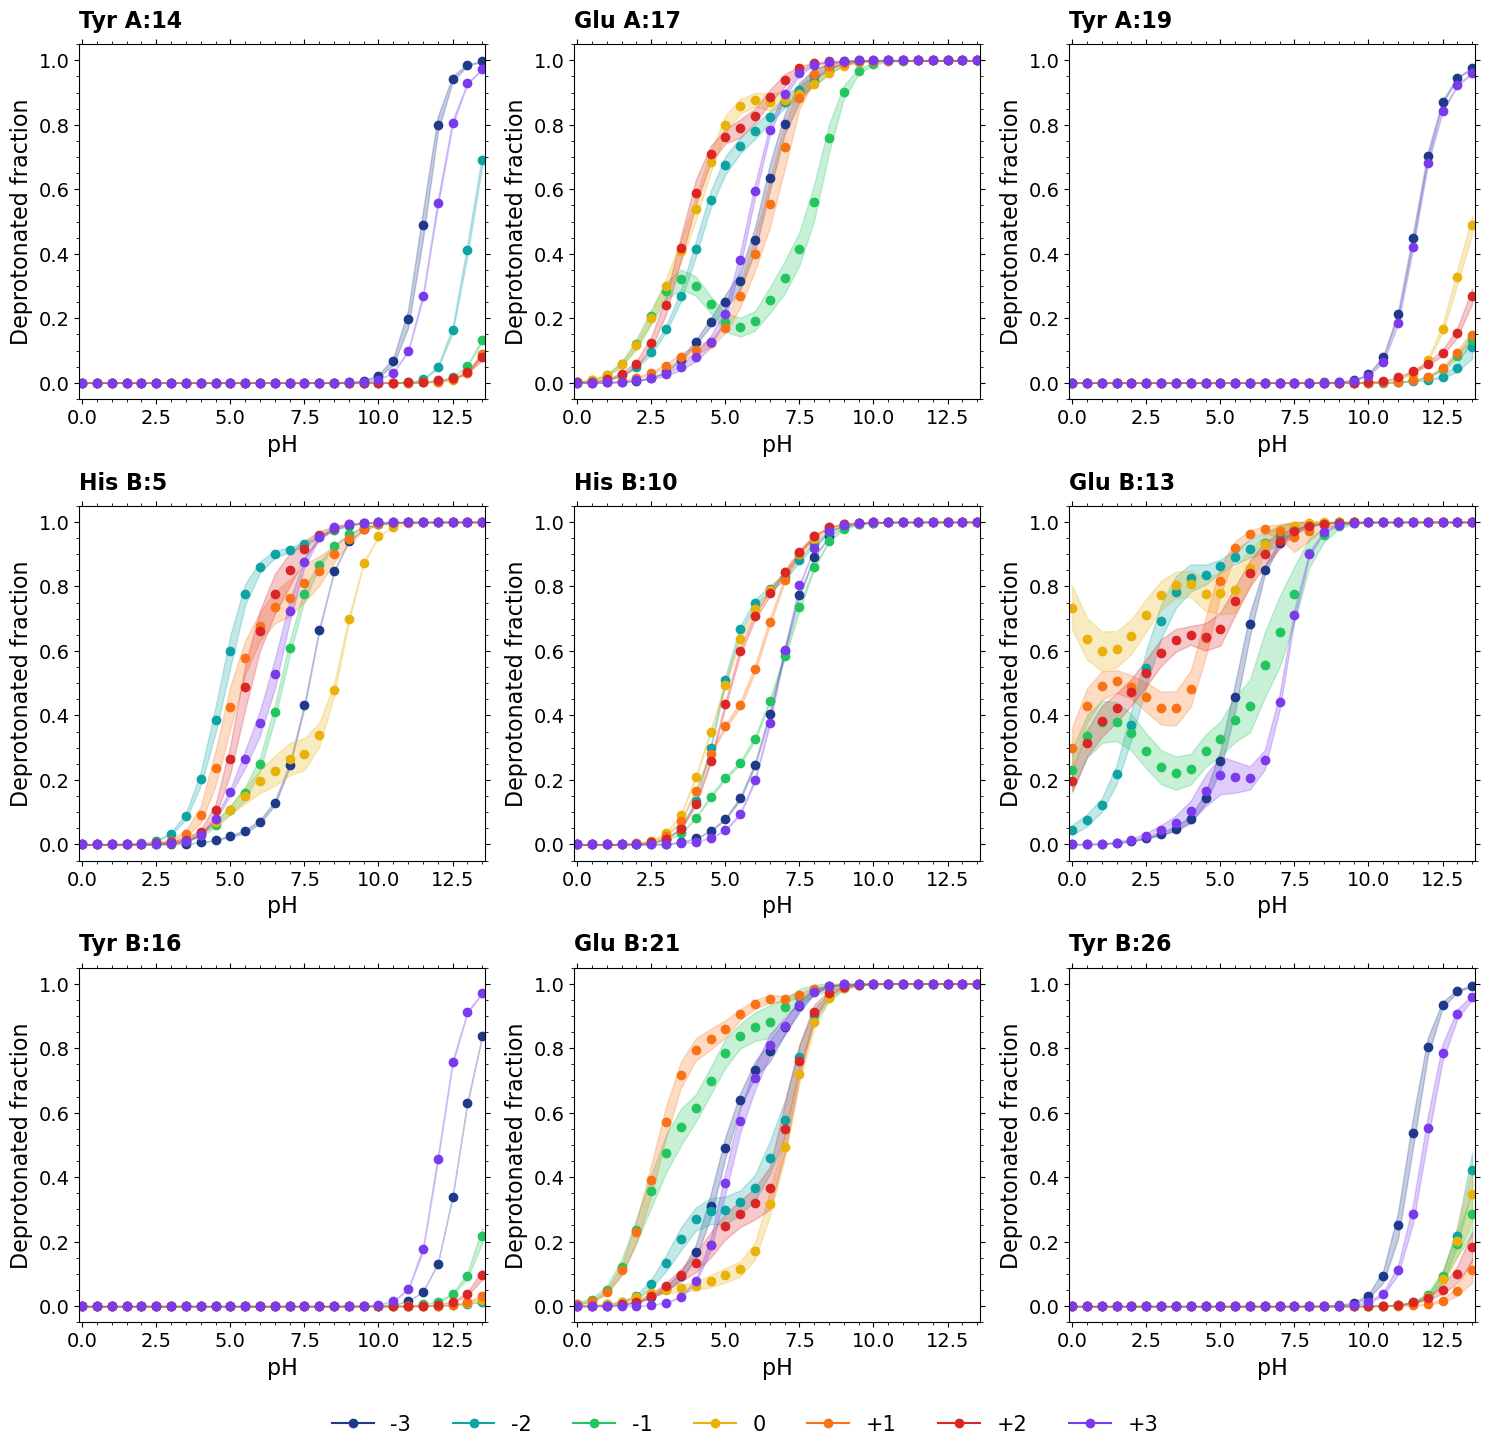

In [6]:
# Function to extract monomer offset from residue label
def get_monomer_index(label):
    # Example label: 'Tyr -1 A:14' → -1
    return int(label.split()[1])

# -----------------------------
# Titration curve visualization
# -----------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes_flat = axes.flatten()

full_palette = [
    "#1F3A8A",
    "#0EA5A4",
    "#22C55E",
    "#EAB308",
    "#F97316",
    "#DC2626",
    "#7C3AED",
]

# Create continuous colormap from your palette
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", full_palette)

def get_colors(n):
    if n == 1:
        return [custom_cmap(0.5)]
    return [custom_cmap(i/(n-1)) for i in range(n)]

# -----------------------------
# Group residues by fibril ID
# -----------------------------

residue_indices = {}

for i, label in enumerate(residue_labels):
    group_id = label.split()[2]
    residue_indices.setdefault(group_id, []).append(i)

desired_order = [
    "A:14", "A:17", "A:19",
    "B:5", "B:10", "B:13",
    "B:16", "B:21", "B:26"
]

ordered_groups = [g for g in desired_order if g in residue_indices]

# -----------------------------
# Mean titration + 95% CI
# -----------------------------

N = fractions_deprotonated.shape[1]

mean_titration_data = fractions_deprotonated.mean(axis=1)
err_titration_data = stats.t.ppf(0.975, df=N-1) * stats.sem(fractions_deprotonated, axis=1)

# -----------------------------
# Plot
# -----------------------------

global_legend_handles = None

for plot_index, group_id in enumerate(ordered_groups):

    ax = axes_flat[plot_index]
    index_group = residue_indices[group_id]

    # Sort indices by monomer offset (-1, 0, +1)
    index_group.sort(key=lambda idx: get_monomer_index(residue_labels[idx]))

    group_colors = get_colors(len(index_group))

    first_label = residue_labels[index_group[0]]
    title = first_label.split()[0] + " " + first_label.split()[2]

    ax.set_title(title, loc='left', fontsize=16, fontweight='bold', pad=12)

    ax.set_xlabel('pH', fontsize=16)
    ax.set_ylabel('Deprotonated fraction', fontsize=16)

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.1, 13.6)

    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    legend_handles = []

    for j, idx in enumerate(index_group):

        color = group_colors[j]
        copy_index = int(residue_labels[idx].split()[1])

        legend_label = residue_labels[idx].split()[1]

        y_mean = mean_titration_data[:, idx]
        err = err_titration_data[:, idx]

        lower = y_mean - err
        upper = y_mean + err

        ax.plot(pHs, y_mean, marker='o', linestyle='None', color=color)
        ax.fill_between(pHs, lower, upper, color=color, alpha=0.25)

        legend_handles.append(
            Line2D([0], [0], color=color, marker='o', linestyle='-', label=legend_label)
        )

    # Store legend handles only once (they're identical across panels)
    if global_legend_handles is None:
        global_legend_handles = legend_handles

# -----------------------------
# Use last subplot for legend
# -----------------------------

fig.legend(
    handles=global_legend_handles,
    frameon=False,
    fontsize=13,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.001),
    ncol=7,
    prop={'size':15}
)

fig.tight_layout()
fig.savefig('Figures/Fibril_7mer_Full_Titration.pdf', bbox_inches='tight', dpi=600)


## Visualize center titration curves

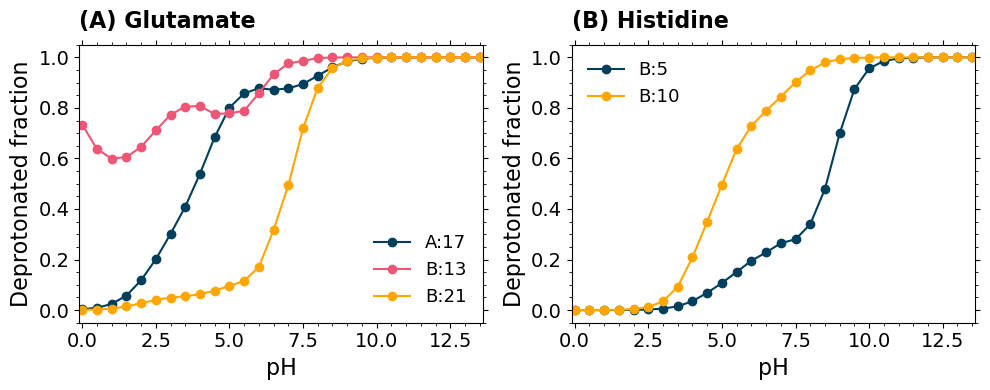

In [26]:
# -----------------------------
# Titration curve visualization
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 0.5*8))
axes_flat = axes.flatten()

full_palette = ['#003f5c', '#7a5195', '#ef5675', '#ffa600']

def get_colors(n, palette):
    if n == 1:
        return [palette[0]]
    elif n == 2:
        return [palette[0], palette[-1]]
    else:
        return [
            palette[int(round(i * (len(palette) - 1) / (n - 1)))]
            for i in range(n)
        ]

# -----------------------------
# Group residues by chemistry
# -----------------------------

DISPLAY_RESNAME = {
    "GLU": "Glu",
    "ASP": "Asp",
    "TYR": "Tyr",
    "HIS": "His",
    "LYS": "Lys",
    "CYS": "Cys"
}

residue_indices = {}

for i, (rn, label) in enumerate(zip(resnames, residue_labels)):

    # Only keep center residues (copy == 0)
    copy_index = label.split()[1]
    if copy_index != "0":
        continue

    display = DISPLAY_RESNAME.get(rn, rn.title())
    residue_indices.setdefault(display, []).append(i)

# Explicit plotting order
ordered_groups = ["Glu", "His"]
index_groups = [residue_indices[g] for g in ordered_groups if g in residue_indices]

group_titles = [
    "(A) Glutamate",
    "(B) Histidine",
]

# Mean titration across blocks
mean_titration_data = fractions_deprotonated.mean(axis=1)

# -----------------------------
# Plot
# -----------------------------

for i, index_group in enumerate(index_groups):

    ax = axes_flat[i]
    group_colors = get_colors(len(index_group), full_palette)

    ax.set_title(group_titles[i], loc='left', fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('pH', fontsize=16)
    ax.set_ylabel('Deprotonated fraction', fontsize=16)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.1, 13.6)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    legend_handles = []

    for j, idx in enumerate(index_group):
        color = group_colors[j]

        # Canonical legend label (A:4, B:13, etc)
        label = residue_labels[idx].split()[2]

        # Mean data points
        y_mean = mean_titration_data[:, idx]
        ax.plot(pHs, y_mean, marker='o', linestyle='solid', color=color)

        # Mean fitted curve
        pka = fitted_pkas[idx]
        nh = fitted_ns[idx]

        legend_handles.append(
            Line2D([0], [0], color=color, marker='o',
                   linestyle='-', label=label)
        )

    ax.legend(handles=legend_handles, frameon=False, fontsize=13, loc="best")

fig.tight_layout()
fig.savefig('Figures/Fibril_7mer_Glu_His_Center_Titration.pdf', bbox_inches='tight', dpi=600)


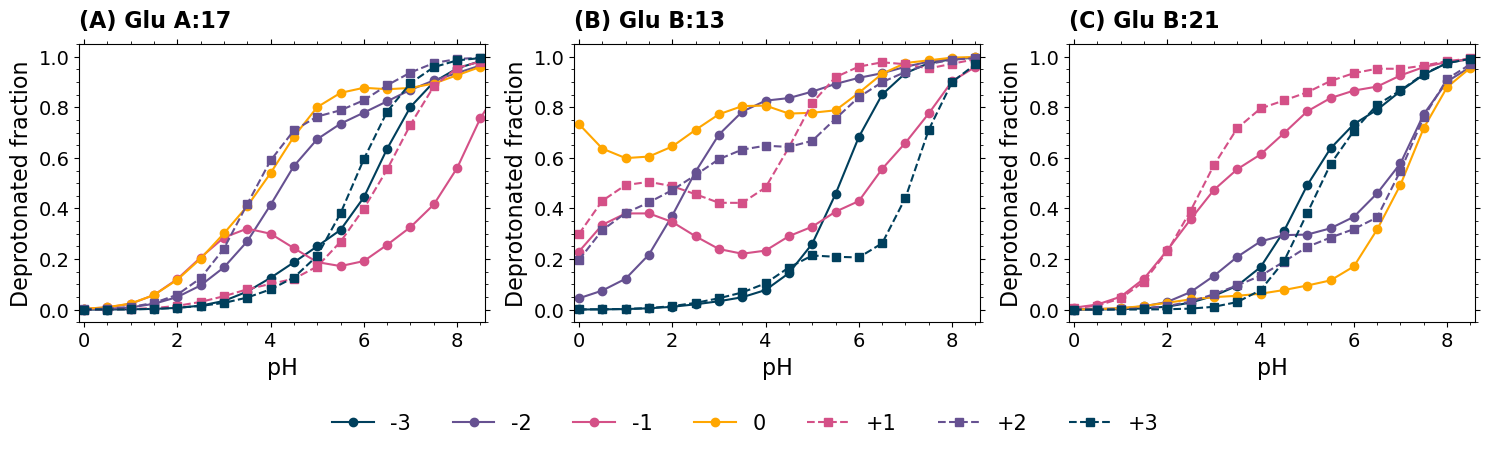

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 0.5*8))
axes_flat = axes.flatten()

palette4 = [
    "#003f5c",  # ±3  Ultimate
    "#665191",  # ±2  Penultimate
    "#d45087",  # ±1  Antepenultimate
    "#ffa600",  #  0  Center
]

sites = ["A:17", "B:13", "B:21"]

glu_indices = {site: [] for site in sites}

for i, label in enumerate(residue_labels):
    if label.startswith("Glu"):
        site = label.split()[2]
        if site in glu_indices:
            glu_indices[site].append(i)

group_titles = [
    "(A) Glu A:17",
    "(B) Glu B:13",
    "(C) Glu B:21"
]

mean_titration = fractions_deprotonated.mean(axis=1)

legend_handles = []
legend_seen = set()

# -----------------------------
# Plot
# -----------------------------

for ax_idx, site in enumerate(sites):

    ax = axes_flat[ax_idx]

    indices = glu_indices[site]
    indices = sorted(indices, key=lambda i: get_monomer_index(residue_labels[i]))

    for idx in indices:

        label = residue_labels[idx]
        offset = get_monomer_index(label)

        color = palette4[{3:0,2:1,1:2,0:3}[abs(offset)]]

        y = mean_titration[:, idx]

        if offset <= 0:
            linestyle = "solid"
            marker = "o"
        else:
            linestyle = "dashed"
            marker = "s"

        ax.plot(pHs, y,
                linestyle=linestyle,
                marker=marker,
                color=color)

        ax.set_title(group_titles[ax_idx], loc='left', fontsize=16, fontweight='bold', pad=12)
        ax.set_xlabel('pH', fontsize=16)
        ax.set_ylabel('Deprotonated fraction', fontsize=16)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(-0.1, 8.6)
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')

        # Legend label
        pos_label = f"{offset:+d}".replace("+0", "0")

        if ax_idx == 0 and pos_label not in legend_seen:
            legend_seen.add(pos_label)

            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=color,
                    marker=marker,
                    linestyle=linestyle,
                    label=pos_label
                )
            )

fig.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=13,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.001),
    ncol=7,
    prop={'size':15}
)

fig.tight_layout()
fig.savefig('Figures/Fibril_7mer_Glu_Titration.pdf', bbox_inches='tight', dpi=600)


## Heatmap

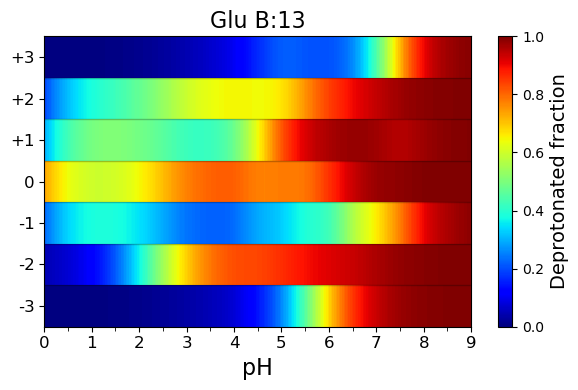

In [9]:
fig, ax = plt.subplots(figsize=(6,4))

# --------------------------------
# Select Glu B:13 residues
# --------------------------------

glu_b13 = []

for i, label in enumerate(residue_labels):
    if label.startswith("Glu") and "B:13" in label:
        offset = int(label.split()[1])
        glu_b13.append((offset, i))

desired_order = [-3, -2, -1, 0, 1, 2, 3]

offset_to_index = {o: idx for o, idx in glu_b13}
sel_indices = [offset_to_index[o] for o in desired_order]

# --------------------------------
# Extract titration data
# --------------------------------

mean_frac = fractions_deprotonated.mean(axis=1)
heat = mean_frac[:, sel_indices].T   # (7 residues × pH)

# --------------------------------
# Interpolate ONLY along pH
# --------------------------------

pH_dense = np.linspace(pHs.min(), pHs.max(), 400)

heat_interp = np.zeros((heat.shape[0], len(pH_dense)))

for i in range(heat.shape[0]):
    f = interp1d(pHs, heat[i, :], kind="cubic")
    heat_interp[i] = f(pH_dense)

# --------------------------------
# Build edges for pcolormesh
# --------------------------------

pH_edges = np.linspace(pH_dense.min(), pH_dense.max(), len(pH_dense)+1)
y_edges = np.arange(8)

# --------------------------------
# Plot
# --------------------------------

mesh = ax.pcolormesh(
    pH_edges,
    y_edges,
    heat_interp,
    cmap="jet",
    vmin=0,
    vmax=1,
    shading="flat",
    rasterized=True
)


# --------------------------------
# Row separators
# --------------------------------

for y in range(1,7):
    ax.axhline(y, color='k', lw=1, alpha=0.25)

# --------------------------------
# Colorbar
# --------------------------------

cbar = fig.colorbar(mesh)
cbar.set_label("Deprotonated fraction", fontsize=14)

# --------------------------------
# Y labels
# --------------------------------

yticks = np.arange(7) + 0.5
ylabels = ["-3","-2","-1","0","+1","+2","+3"]

ax.set_yticks(yticks, ylabels)

# --------------------------------
# Axis formatting
# --------------------------------

ax.set_xlabel("pH", fontsize=16)
ax.set_title("Glu B:13", fontsize=16)

ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', length=3)

ax.set_xlim(pHs[0], 9)

fig.tight_layout()
fig.savefig('Figures/Fibril_7mer_GluB13_Heatmap.pdf', bbox_inches='tight', dpi=600)


/tmp/ipykernel_710498/1913220925.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


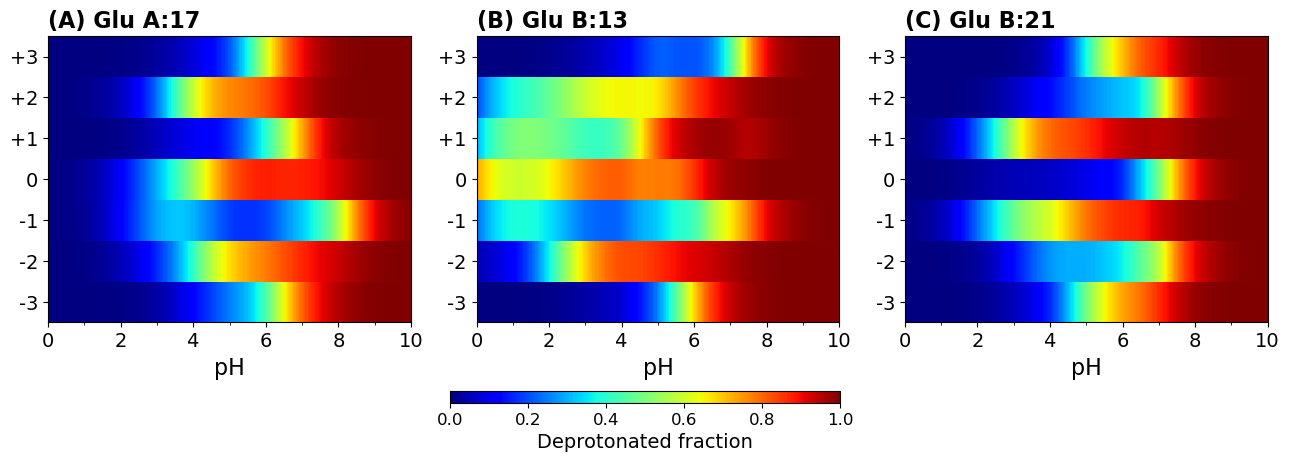

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 0.5*8))
axes_flat = axes.flatten()

sites = ["A:17", "B:13", "B:21"]

group_titles = [
    "(A) Glu A:17",
    "(B) Glu B:13",
    "(C) Glu B:21"
]

position_labels = ["-3","-2","-1","0","+1","+2","+3"]
desired_offsets = [-3,-2,-1,0,1,2,3]

glu_by_site = {site: [] for site in sites}

for i, label in enumerate(residue_labels):
    if label.startswith("Glu"):
        tokens = label.split()
        offset = int(tokens[1])
        site = tokens[2]
        if site in glu_by_site:
            glu_by_site[site].append((offset, i))

mean_frac = fractions_deprotonated.mean(axis=1)   # (pH, residue)

# dense pH grid (for continuous X)
pH_dense = np.linspace(pHs.min(), pHs.max(), 400)
pH_edges = np.linspace(pHs.min(), pHs.max(), 401)

y_edges = np.arange(8)

for ax_idx, site in enumerate(sites):

    ax = axes_flat[ax_idx]

    glu_list = glu_by_site[site]
    offset_to_idx = {o: idx for o, idx in glu_list}
    sel_indices = [offset_to_idx[o] for o in desired_offsets]

    data = mean_frac[:, sel_indices].T   # (7, n_pH)

    # interpolate only along pH
    heat_interp = np.zeros((data.shape[0], len(pH_dense)))

    for i in range(data.shape[0]):
        f = interp1d(pHs, data[i], kind="cubic")
        heat_interp[i] = f(pH_dense)

    # heatmap
    mesh = ax.pcolormesh(
        pH_edges,
        y_edges,
        heat_interp,
        cmap="jet",
        vmin=0,
        vmax=1,
        shading="flat",
        rasterized=True
    )

    ax.set_title(group_titles[ax_idx], loc='left', fontsize=16, fontweight='bold')
    ax.set_xlabel("pH", fontsize=16)

    ax.set_yticks(np.arange(7)+0.5)
    ax.set_yticklabels(position_labels)

    ax.tick_params(axis='both', which='major', labelsize=14)

    ax.set_xlim(pHs.min(), 10)
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

# colorbar
cax = fig.add_axes([0.35, -0.02, 0.3, 0.03])
cbar = fig.colorbar(mesh, cax=cax, orientation="horizontal")
cbar.set_label("Deprotonated fraction", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.tight_layout()
fig.savefig("Figures/Fibril_7mer_Glu_Heatmaps.pdf", bbox_inches="tight", dpi=600)


## Axial offsets in Fibril

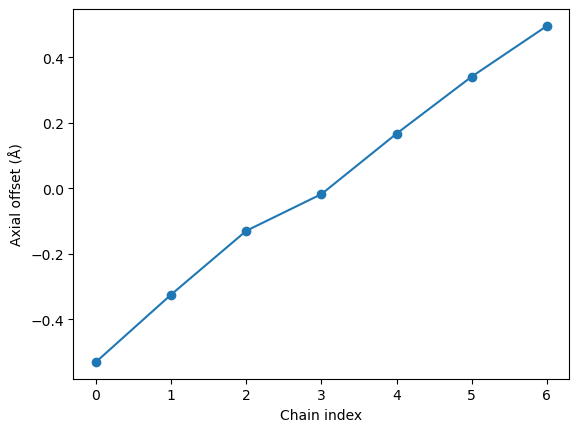

In [11]:
# -----------------------------
# Load structure
# -----------------------------

pdb = md.load('fibril_7/0_preparation/insulin_fibril_leap_output.pdb')
pdb.remove_solvent(inplace=True)

top = pdb.topology

# Extract offsets (-3,-1,-2,+1,0,+3,+2)
offsets = []

for label in residue_labels:
    offsets.append(int(label.split()[1]))

offsets = np.array(offsets)

# Each insulin = 5 residues in your list
# so insulin index = residue_index // 5

insulin_offsets = {}

for i, off in enumerate(offsets):
    mol = i // 9
    insulin_offsets[mol] = off

# Unique insulin offsets
insulin_offsets = np.array([insulin_offsets[i] for i in sorted(insulin_offsets)])

# Desired symmetric order
desired_order = [-3,-2,-1,0,1,2,3]

offset_to_mol = {o:i for i,o in enumerate(insulin_offsets)}
mol_order = [offset_to_mol[o] for o in desired_order]

# -----------------------------
# Backbone atoms for PCA
# -----------------------------

bb = top.select("name N or name CA or name C or name O")
X = pdb.xyz[0, bb, :]
X -= X.mean(axis=0)

cov = np.cov(X.T)
vals, vecs = np.linalg.eigh(cov)

fibril_axis = vecs[:, -1]
fibril_axis /= np.linalg.norm(fibril_axis)

origin = pdb.xyz[0, bb, :].mean(axis=0)

# -----------------------------
# Collect chains per insulin
# -----------------------------

chains = list(top.chains)

# insulin = 2 chains
insulin_chains = [
    (chains[i], chains[i+1]) for i in range(0,len(chains),2)
]

# -----------------------------
# Compute axial position per insulin
# -----------------------------

axial = []

for chA, chB in insulin_chains:

    atoms = []

    for ch in (chA,chB):
        atoms += [a.index for a in ch.atoms if a.name in ["N","CA","C","O"]]

    r = pdb.xyz[:, atoms, :].mean(axis=1)
    rmean = r.mean(axis=0)

    s = np.dot(rmean-origin, fibril_axis)
    axial.append(s)

axial = np.array(axial)

# Center
axial -= axial.mean()

# -----------------------------
# Reorder by semantic fibril order
# -----------------------------

axial_sorted = axial[mol_order]

plt.plot(axial_sorted*10, "o-")
plt.xlabel("Chain index")
plt.ylabel("Axial offset (Å)")
plt.show()


## Visualization of sidechain contacts

In [14]:
topology = md.load('fibril_7/0_preparation/insulin_fibril_leap_output.pdb')
topology.remove_solvent(inplace=True)

chains = list(topology.top.chains)

print("Number of chains:", len(chains))
assert len(chains) % 2 == 0

# Build insulin monomers (A+B)
n_monomers = len(chains)//2
monomers = []

for i in range(n_monomers):
    A = chains[2*i]
    B = chains[2*i+1]
    atoms = [a.index for a in A.atoms] + [a.index for a in B.atoms]
    monomers.append(atoms)

def sidechain_heavy(atom):
    return (not atom.is_backbone) and atom.element.symbol != 'H'

# sidechain heavy atoms per monomer
monomers_sc = []

for m in monomers:
    sc = [a.index for a in topology.top.atoms
          if a.index in m and sidechain_heavy(a)]
    monomers_sc.append(sc)

# GLU sidechain heavy atoms per monomer
monomers_glu = []

for m in monomers:
    glu = []
    for a in topology.top.atoms:
        if a.index in m and a.residue.name == 'GL4' and sidechain_heavy(a):
            glu.append(a.index)
    monomers_glu.append(glu)

# non-GLU sidechain atoms per monomer
monomers_non_glu = []

for i in range(n_monomers):
    nonglu = list(set(monomers_sc[i]) - set(monomers_glu[i]))
    monomers_non_glu.append(nonglu)


def block_average_contacts(traj, groupA, groupB, cutoff=0.45, n_blocks=20):

    pairs = np.array([[i, j] for i in groupA for j in groupB])
    n_frames = traj.n_frames

    # Safe block handling
    n_blocks = min(n_blocks, n_frames)
    block_size = max(1, n_frames // n_blocks)

    C_blocks = []

    for i in range(n_blocks):
        start = i * block_size
        stop  = min((i + 1) * block_size, n_frames)
        if start >= stop:
            continue

        block = traj[start:stop]
        d = md.compute_distances(block, pairs)
        contacts = (d < cutoff).sum(axis=1)
        C_blocks.append(contacts.mean())

    C_blocks = np.array(C_blocks)

    mean = C_blocks.mean()
    ci95 = stats.sem(C_blocks) * stats.t.ppf(0.975, len(C_blocks)-1)

    return mean, ci95


Number of chains: 14


In [16]:
# Physical stacking order (indices in monomers list)
stack_order = [0, 2, 1, 4, 3, 6, 5]

# Build physical neighbor pairs
neighbor_pairs = [(stack_order[i], stack_order[i+1])
                  for i in range(len(stack_order)-1)]


C_tot = []
C_tot_err = []

C_glu_glu = []
C_glu_glu_err = []

C_glu_other = []
C_glu_other_err = []

C_other_other = []
C_other_other_err = []

for pH in tqdm(pHs, desc="Processing pH values"):

    traj = md.load(
        f'fibril_7/4_production/pH{pH:.1f}/insulin_fibril.constant_pH{pH:.1f}.nc',
        top=topology
    )

    tot = 0
    tot_err_sq = 0

    gg = 0
    gg_err_sq = 0

    go = 0
    go_err_sq = 0

    oo = 0
    oo_err_sq = 0

    # Loop over TRUE physical neighbor pairs
    for i, j in neighbor_pairs:

        # TOTAL sidechain contacts
        C, e = block_average_contacts(traj,
                                      monomers_sc[i],
                                      monomers_sc[j])
        tot += C
        tot_err_sq += e**2

        # GLU–GLU
        G, ge = block_average_contacts(traj,
                                       monomers_glu[i],
                                       monomers_glu[j])
        gg += G
        gg_err_sq += ge**2

        # GLU–OTHER
        GO1, goe1 = block_average_contacts(traj,
                                           monomers_glu[i],
                                           monomers_non_glu[j])
        GO2, goe2 = block_average_contacts(traj,
                                           monomers_non_glu[i],
                                           monomers_glu[j])
        go += GO1 + GO2
        go_err_sq += goe1**2 + goe2**2

        # OTHER–OTHER
        OO, ooe = block_average_contacts(traj,
                                         monomers_non_glu[i],
                                         monomers_non_glu[j])
        oo += OO
        oo_err_sq += ooe**2

    C_tot.append(tot)
    C_tot_err.append(np.sqrt(tot_err_sq))

    C_glu_glu.append(gg)
    C_glu_glu_err.append(np.sqrt(gg_err_sq))

    C_glu_other.append(go)
    C_glu_other_err.append(np.sqrt(go_err_sq))

    C_other_other.append(oo)
    C_other_other_err.append(np.sqrt(oo_err_sq))


Processing pH values:   0%|                                                                                      | 0/28 [00:00<?, ?it/s]/data9/stefan/miniconda3/envs/gaff_resp2/lib/python3.10/site-packages/mdtraj/formats/netcdf.py:154: UserWarning: Warning: The 'netCDF4' Python package is not installed. MDTraj is using the 'scipy' implementation to read and write netCDF files,which can be significantly slower.
For improved performance, consider installing netCDF4. See installation instructions at:
https://unidata.github.io/netcdf4-python/#quick-install
  warnings.warn(warning_message)
Processing pH values: 100%|██████████████████████████████████████████████████████████████████████████| 28/28 [2:28:11<00:00, 317.57s/it]


In [18]:
C_tot = np.array(C_tot)
C_tot_err = np.array(C_tot_err)

C_glu_glu = np.array(C_glu_glu)
C_glu_glu_err = np.array(C_glu_glu_err)

C_glu_other = np.array(C_glu_other)
C_glu_other_err = np.array(C_glu_other_err)

C_other_other = np.array(C_other_other)
C_other_other_err = np.array(C_other_other_err)

C_tot_norm = C_tot / C_tot[0]
C_tot_err_norm = C_tot_err / C_tot[0]

C_glu_glu_norm = C_glu_glu / C_glu_glu[0]
C_glu_glu_err_norm = C_glu_glu_err / C_glu_glu[0]

C_glu_other_norm = C_glu_other / C_glu_other[0]
C_glu_other_err_norm = C_glu_other_err / C_glu_other[0]

C_other_other_norm = C_other_other / C_other_other[0]
C_other_other_err_norm = C_other_other_err / C_other_other[0]


# -----------------------------
# Save Contact and Normalization Data
# -----------------------------
np.savez_compressed(
    "fibril_7/data/contact_normalization_stats.npz",
    # Raw arrays
    C_tot=C_tot,
    C_tot_err=C_tot_err,
    C_glu_glu=C_glu_glu,
    C_glu_glu_err=C_glu_glu_err,
    C_glu_other=C_glu_other,
    C_glu_other_err=C_glu_other_err,
    C_other_other=C_other_other,
    C_other_other_err=C_other_other_err,
    # Normalized arrays
    C_tot_norm=C_tot_norm,
    C_tot_err_norm=C_tot_err_norm,
    C_glu_glu_norm=C_glu_glu_norm,
    C_glu_glu_err_norm=C_glu_glu_err_norm,
    C_glu_other_norm=C_glu_other_norm,
    C_glu_other_err_norm=C_glu_other_err_norm,
    C_other_other_norm=C_other_other_norm,
    C_other_other_err_norm=C_other_other_err_norm
)


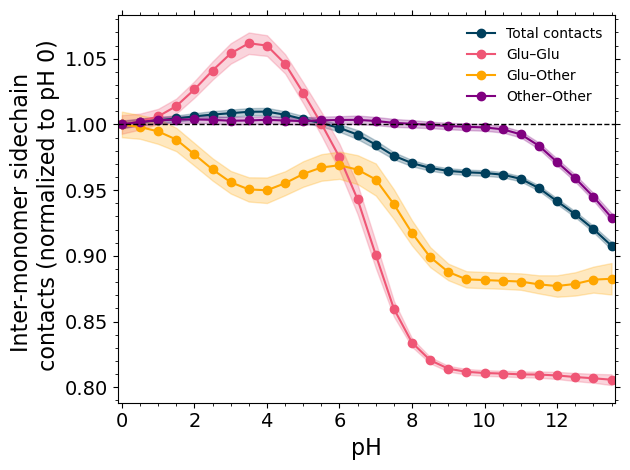

In [22]:
fig, ax = plt.subplots()

colors = get_colors(3, ['#003f5c', '#7a5195', '#ef5675', '#ffa600'])

# Total
ax.plot(pHs, C_tot_norm, 'o-', label='Total contacts', color=colors[0])
ax.fill_between(pHs, C_tot_norm - C_tot_err_norm,C_tot_norm + C_tot_err_norm, alpha=0.25, color=colors[0])

# Glu–Glu
ax.plot(pHs, C_glu_glu_norm, 'o-', label='Glu–Glu', color=colors[1])
ax.fill_between(pHs, C_glu_glu_norm - C_glu_glu_err_norm, C_glu_glu_norm + C_glu_glu_err_norm, alpha=0.25, color=colors[1])

# Glu–Other
ax.plot(pHs, C_glu_other_norm, 'o-', label='Glu–Other', color=colors[2])
ax.fill_between(pHs, C_glu_other_norm - C_glu_other_err_norm, C_glu_other_norm + C_glu_other_err_norm, alpha=0.25, color=colors[2])

# Other–Other
ax.plot(pHs, C_other_other_norm, 'o-', label='Other–Other', color='purple')
ax.fill_between(pHs, C_other_other_norm - C_other_other_err_norm, C_other_other_norm + C_other_other_err_norm, alpha=0.25, color='purple')

ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_xlabel('pH', fontsize=16)
ax.set_ylabel('Inter-monomer sidechain \n contacts (normalized to pH 0)', fontsize=16)
ax.set_xlim(-0.1, 13.6)
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig('Figures/Fibril_7mer_Contacts.pdf')
